<a href="https://colab.research.google.com/github/shannigrahiayan36-dot/cifar10/blob/main/cifar10normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Image Classification with Deep Neural Networks

This notebook demonstrates a deep learning approach to classifying images from the CIFAR-10 dataset using TensorFlow and Keras. The project covers data preprocessing, scaling, and training a deep MLP with modern optimization techniques.

In [ ]:
import numpy, pandas, matplotlib

## 1. Model Architecture

We define a Sequential model with 20 hidden layers, each containing 100 neurons. We use the **ELU** activation function and **He Normal** initialization, which are well-suited for deep networks to prevent vanishing/exploding gradients.

In [ ]:
from tensorflow import keras

model = keras.models.Sequential([
keras.layers.Flatten(input_shape=[32,32,3]),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 2. Data Loading and Preprocessing

First, we load the CIFAR-10 dataset. To ensure the model converges effectively, we normalize the pixel values to a range between 0 and 1 by dividing by 255.

In [ ]:
Data=keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = Data

print(f"Original train images shape: {X_train_full.shape}")

# Normalize pixel values to range [0, 1]
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

print(f"Normalized X_train_full shape: {X_train_full.shape}")
print(f"Normalized X_test shape: {X_test.shape}")

Original train images shape: (50000, 32, 32, 3)
Normalized X_train_full shape: (50000, 32, 32, 3)
Normalized X_test shape: (10000, 32, 32, 3)


In [ ]:
# Creating validation set
# Pixel values are normalized [0, 1] in the previous step.
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

print(f"Validation set shape: {X_valid.shape}")
print(f"New training set shape: {X_train.shape}")

Validation set shape: (5000, 32, 32, 3)
New training set shape: (45000, 32, 32, 3)


### Data Visualization

It is important to verify the data. Here we visualize a sample image from the training set. Note that since the data is standardized (mean 0, variance 1), the pixel values may appear clipped in standard viewers.

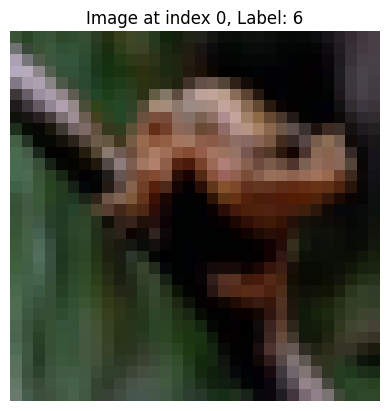

In [ ]:
import matplotlib.pyplot as plt

#loding a image
first_image = X_train[0]
first_label = y_train[0]

# Display the image
plt.imshow(first_image)
plt.title(f"Image at index {0}, Label: {first_label[0]}")
plt.axis('off') # Hide axes for a cleaner look
plt.show()

## 3. Optimization and Training

We use the **Nadam** optimizer for faster convergence and implement **Early Stopping**. Early stopping monitors the validation loss and restores the best weights if the model stops improving, preventing overfitting.

In [ ]:
optimizer = keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

In [ ]:
import tensorflow as tf

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    mode='min'
)

In [ ]:
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid), callbacks=[early_stopping], epochs=100)

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.2718 - loss: 2.0097 - val_accuracy: 0.3086 - val_loss: 1.9021
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3405 - loss: 1.8140 - val_accuracy: 0.3326 - val_loss: 1.8625
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3642 - loss: 1.7563 - val_accuracy: 0.3720 - val_loss: 1.7899
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.3884 - loss: 1.7094 - val_accuracy: 0.3582 - val_loss: 1.7685
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.4031 - loss: 1.6786 - val_accuracy: 0.3804 - val_loss: 1.7360
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.4122 - loss: 1.6435 - val_accuracy: 0.3978 - val_loss: 1.7566
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.2995 - loss: 1.9547 - val_accuracy: 0.1856 - val_loss: 2.1259
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 

## 4. Performance Evaluation

Finally, we plot the training and validation accuracy and loss curves to analyze the model's learning behavior over time.

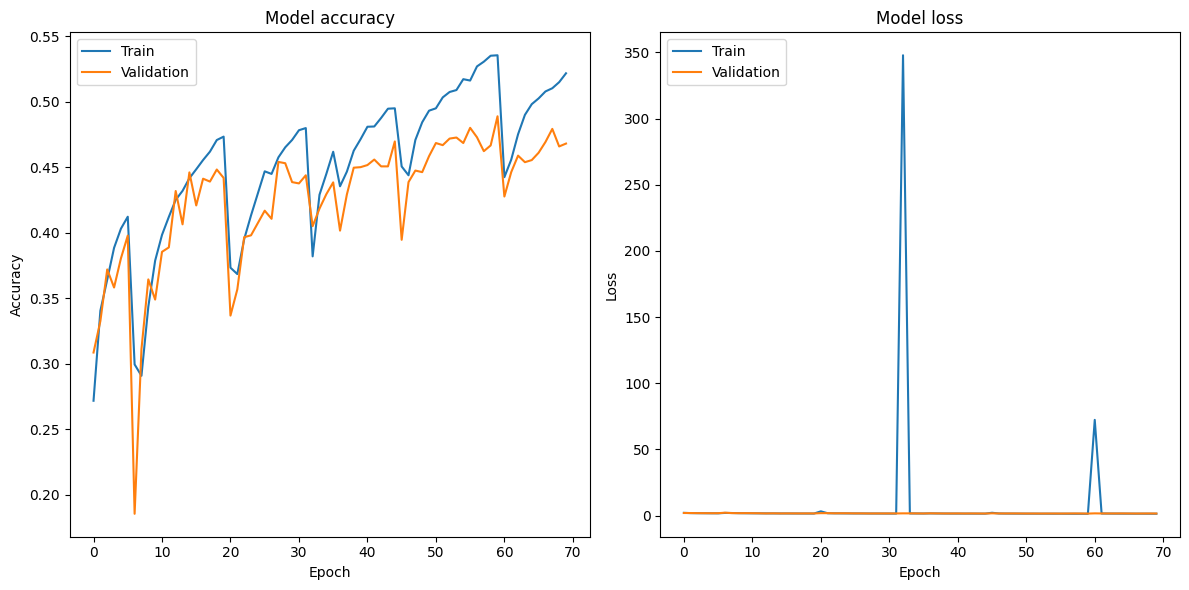

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()